In [1]:
pip install numpy pandas matplotlib scikit-learn

  Using cached numpy-2.5.3-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.5-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (9.3 kB)
  Using cached contourpy-1.4.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (125 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 k

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.DataFrame({"ticket":[1,2,3],
"priorite":["haute","basse","moyenne"]})
df

,ticket,priorite
0,1,haute
1,2,basse
2,3,moyenne


In [2]:
import pandas as pd


In [5]:
df = pd.read_csv("/Users/alexiscrozier/code/data_ia/venv/training_01/data/data_J1_brut.csv")

In [7]:
df.columns.to_list()

['machine_id',
 'ville',
 'type_machine',
 'risque',
 'temperature_C',
 'vibration',
 'pression_bar',
 'age_ans',
 'production_jour',
 'panne']

In [8]:
df.dtypes.to_dict()

{'machine_id': <StringDtype(storage='python', na_value=nan)>,
 'ville': <StringDtype(storage='python', na_value=nan)>,
 'type_machine': <StringDtype(storage='python', na_value=nan)>,
 'risque': <StringDtype(storage='python', na_value=nan)>,
 'temperature_C': dtype('float64'),
 'vibration': dtype('float64'),
 'pression_bar': dtype('float64'),
 'age_ans': dtype('int64'),
 'production_jour': dtype('float64'),
 'panne': dtype('int64')}

In [14]:
types = df.dtypes.to_dict()

for column, type in types.items():
    print(f"{column} : {type}")


machine_id : str
ville : str
type_machine : str
risque : str
temperature_C : float64
vibration : float64
pression_bar : float64
age_ans : int64
production_jour : float64
panne : int64


In [15]:
df.isnull().sum()

machine_id          0
ville               0
type_machine       12
risque              0
temperature_C      22
vibration          28
pression_bar       20
age_ans             0
production_jour     0
panne               0
dtype: int64

In [16]:
df[df.duplicated(keep=False)]

,machine_id,ville,type_machine,risque,temperature_C,vibration,pression_bar,age_ans,production_jour,panne
12,M0013,Parakou,Pompe,Faible,60.4,5.36,6.34,11,12083.0,0
57,M0058,Cotonou,Moteur,Faible,79.4,4.47,7.17,8,36423.0,0
201,M0202,Parakou,Pompe,Moyen,74.7,4.40,7.16,17,36809.0,0
420,M0013,Parakou,Pompe,Faible,60.4,5.36,6.34,11,12083.0,0
421,M0058,Cotonou,Moteur,Faible,79.4,4.47,7.17,8,36423.0,0
422,M0202,Parakou,Pompe,Moyen,74.7,4.40,7.16,17,36809.0,0


In [17]:
df.nunique()

machine_id         420
ville                4
type_machine         3
risque               3
temperature_C      218
vibration          279
pression_bar       193
age_ans             17
production_jour    417
panne                2
dtype: int64

In [18]:
nb_lignes = len(df)
df_cardinalite = pd.DataFrame({
    'Colonne': df.columns,
    'Cardinalité': df.nunique().values,
    'Ratio (%)': ((df.nunique() / nb_lignes) * 100).round(2).values
})
df_cardinalite = df_cardinalite.sort_values(by='Cardinalité', ascending=False)

print(df_cardinalite)

           Colonne  Cardinalité  Ratio (%)
0       machine_id          420      99.29
8  production_jour          417      98.58
5        vibration          279      65.96
4    temperature_C          218      51.54
6     pression_bar          193      45.63
7          age_ans           17       4.02
1            ville            4       0.95
2     type_machine            3       0.71
3           risque            3       0.71
9            panne            2       0.47


In [19]:
len(df)

423

In [21]:
import matplotlib.pyplot as plt


In [23]:
!pip install seaborn



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [24]:
import seaborn as sns

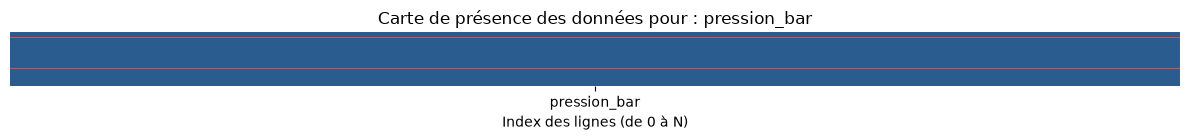

In [27]:
plt.figure(figsize=(12, 1.5))

sns.heatmap(
    df[['pression_bar']].isnull(), 
    cmap=['#2b5c8f', '#e74c3c'],
    cbar=False, 
    yticklabels=False
)

plt.title(f'Carte de présence des données pour : {'pression_bar'}', fontsize=12)
plt.xlabel('Index des lignes (de 0 à N)')
plt.tight_layout()
plt.show()

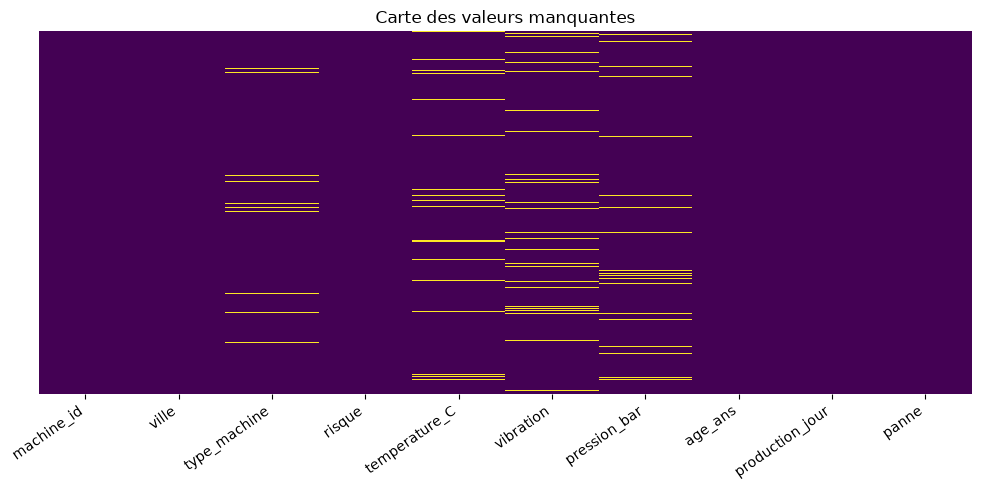

In [29]:
plt.figure(figsize=(10, 5))

# sns.heatmap sur TOUT le dictionnaire de valeurs manquantes
sns.heatmap(
    df.isnull(), 
    cmap='viridis',     # La palette violet/jaune de l'image
    cbar=False,          # Supprime la barre d'échelle
    yticklabels=False    # Supprime les numéros de lignes sur l'axe vertical
)

plt.title('Carte des valeurs manquantes', fontsize=12)

# Incliner les noms des colonnes à 35-45 degrés comme sur l'image
plt.xticks(rotation=35, ha='right')

plt.tight_layout()
plt.show()

In [31]:
pd.set_option('display.max_columns', None)  # Affiche TOUTES les colonnes
pd.set_option('display.max_rows', None)     # Affiche TOUTES les lignes
pd.set_option('display.width', 1000)        # Évite le retour à la ligne automatique

In [32]:
lignes_avec_nan = df[df.isnull().any(axis=1)]

print(lignes_avec_nan)

    machine_id          ville type_machine  risque  temperature_C  vibration  pression_bar  age_ans  production_jour  panne
0        M0001  Abomey-Calavi  Compresseur  Faible            NaN   3.000000          6.65       13     21256.000000      0
2        M0003        Parakou        Pompe  Faible           77.5        NaN          7.11       15     20511.000000      0
3        M0004  Abomey-Calavi        Pompe  Faible           72.5   3.120000           NaN        9     31192.000000      0
6        M0007        Parakou        Pompe  Faible           77.0        NaN          7.17       13     28151.000000      0
11       M0012        Cotonou        Pompe   Moyen           64.8   1.970000           NaN       14     29606.000000      0
24       M0025        Parakou       Moteur  Faible           66.1        NaN          6.72       10     33927.000000      0
32       M0033  Abomey-Calavi  Compresseur   Moyen            NaN   4.700000          7.40        1     12789.000000      0
36      

In [33]:
lignes_pression_absente = df[df['pression_bar'].isnull()]

with pd.option_context('display.max_columns', None):
    print(lignes_pression_absente)

    machine_id          ville type_machine  risque  temperature_C  vibration  pression_bar  age_ans  production_jour  panne
3        M0004  Abomey-Calavi        Pompe  Faible           72.5   3.120000           NaN        9     31192.000000      0
11       M0012        Cotonou        Pompe   Moyen           64.8   1.970000           NaN       14     29606.000000      0
40       M0041        Cotonou        Pompe   Moyen           67.8   3.430000           NaN       15     42250.000000      0
52       M0053        Cotonou        Pompe   Moyen           70.3   1.060000           NaN        7     34305.000000      0
104      M0105  Abomey-Calavi       Moteur  Faible           58.2   3.230000           NaN        6     28576.000000      0
122      M0123        Cotonou        Pompe   Moyen           68.8   4.360000           NaN        6     28902.000000      0
191      M0192        Cotonou  Compresseur   Moyen            NaN   2.440000           NaN       10     33941.000000      0
205     

In [34]:
lignes_pression_absente = df[df['vibration'].isnull()]

with pd.option_context('display.max_columns', None):
    print(lignes_pression_absente)

    machine_id    ville type_machine  risque  temperature_C  vibration  pression_bar  age_ans  production_jour  panne
2        M0003  Parakou        Pompe  Faible           77.5        NaN          7.11       15          20511.0      0
6        M0007  Parakou        Pompe  Faible           77.0        NaN          7.17       13          28151.0      0
24       M0025  Parakou       Moteur  Faible           66.1        NaN          6.72       10          33927.0      0
36       M0037  Parakou       Moteur   Élevé           77.2        NaN          7.09        1          33254.0      0
46       M0047  Parakou       Moteur  Faible           72.0        NaN          6.08       10          32453.0      0
48       M0049  Parakou        Pompe  Faible           77.9        NaN          7.10       17          24029.0      0
92       M0093  Parakou        Pompe  Faible           72.2        NaN          6.83        7          39368.0      0
116      M0117  Parakou  Compresseur   Moyen           6

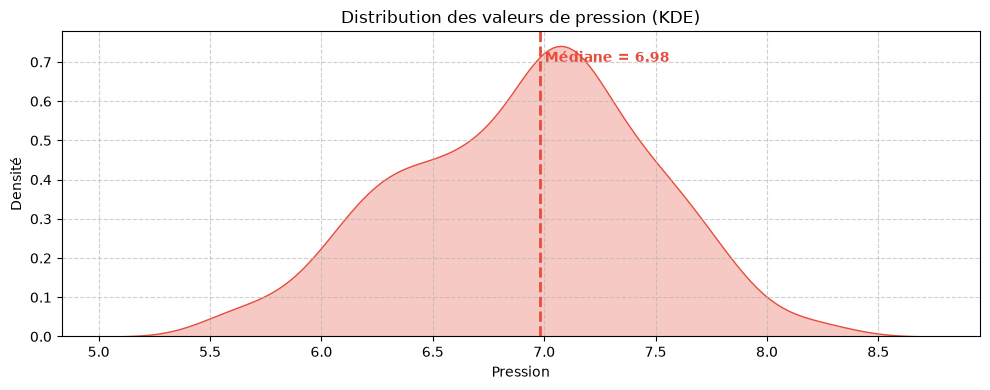

In [37]:
plt.figure(figsize=(10, 4))
sns.kdeplot(df['pression_bar'].dropna(), color='#e74c3c', fill=True, alpha=0.3)

mediane = df['pression_bar'].median()

plt.axvline(
    x=mediane, 
    color='#e74c3c', 
    linestyle='--', 
    linewidth=2, 
    label=f'Médiane : {mediane:.2f}'
)

plt.text(
    x=mediane, 
    y=plt.ylim()[1] * 0.9,  # Place le texte en haut du graphique
    s=f' Médiane = {mediane:.2f}', 
    color='#e74c3c', 
    fontweight='bold'
)

plt.title('Distribution des valeurs de pression (KDE)')
plt.xlabel('Pression')
plt.ylabel('Densité')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()